In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt 
import numpy as np

In [6]:
X,y = make_classification(
    n_samples=1000,
    n_informative=10,
    random_state=2022
)
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=2022
)
print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

X_train shape: (800, 20)
y_train shape: (800,)
X_test shape: (200, 20)
y_test shape: (200,)


In [12]:
model = tf.keras.Sequential([
    # Added a comma after X_train.shape[1] to make it a proper tuple
    tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    # Note: If this is a multi-label classification, sigmoid is fine. 
    # If it's multi-class (one mutually exclusive choice), use 'softmax'.
    tf.keras.layers.Dense(1, activation='sigmoid') 
])

model.compile(
    optimizer='adam', # Changed 'ada' to 'adam'
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20


/workspaces/AI_NN_2/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4062 - loss: 0.7829 - val_accuracy: 0.4550 - val_loss: 0.7497
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4575 - loss: 0.7197 - val_accuracy: 0.5200 - val_loss: 0.7066
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5213 - loss: 0.6815 - val_accuracy: 0.5400 - val_loss: 0.6768
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5788 - loss: 0.6508 - val_accuracy: 0.5850 - val_loss: 0.6448
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6187 - loss: 0.6229 - val_accuracy: 0.6400 - val_loss: 0.6096
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6600 - loss: 0.5901 - val_accuracy: 0.6750 - val_loss: 0.5732
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7113 - loss: 0.5515 - val_accuracy: 0.7150 - val_loss: 0.5353
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7600 - loss: 0.5104 - val_accuracy: 0.7700 - val_loss: 0.4931
Epo

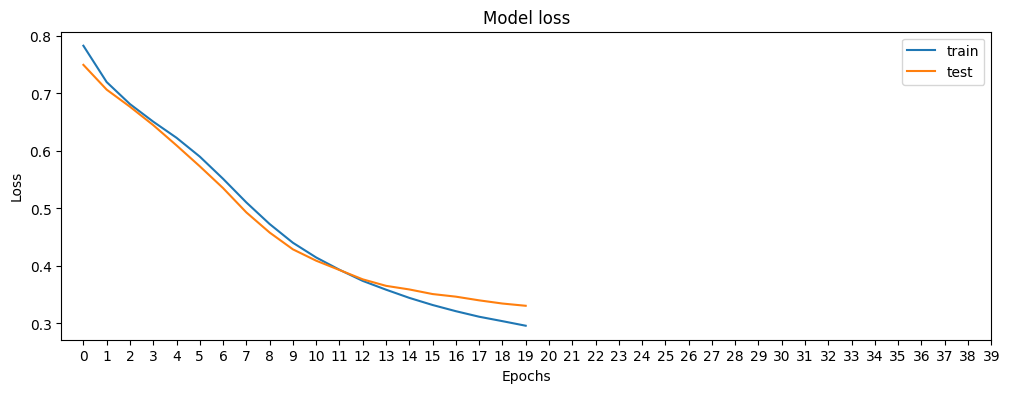

In [16]:
fig,ax=plt.subplots(figsize=(12,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epochs')  
plt.ylabel('Loss')    
plt.xticks(np.arange(0,40,1))
plt.legend(['train','test'],loc='upper right')
plt.show()